# Classificação Textual de Reviews da Steam
### Autores: Daniel Vaz, Kauê Barbosa

O objetivo deste trabalho é aplicar técnicas de Processamento de Linguagem Natural (PLN) para realizar a análise de sentimento de reviews de jogos da plataforma Steam, construindo e avaliando modelos de classificação de texto. Para isso, foram realizadas etapas de pré-processamento, representação dos documentos em espaços vetoriais utilizando Bag-of-Words e TF-IDF e, por fim, o treinamento e a comparação de dois algoritmos de classificação supervisionada — Naive Bayes Multinomial e Regressão Logística — na tarefa de prever se uma review recomenda ou não o jogo (variável voted_up). A partir dos resultados obtidos, busca-se analisar o impacto das diferentes representações de texto e dos modelos utilizados no desempenho da classificação.

In [30]:
# Imports da biblioteca padrão
import ast
from collections import Counter

# Bibliotecas de ciência de dados e visualização
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
# import nltk
# nltk.download('punkt_tab')
# nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy

# Amostragem e balanceamento
from imblearn.under_sampling import RandomUnderSampler

# Modelagem e avaliação (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Pré-processamento e Limpeza Textual

Nesta seção, descrevemos o processo de pré-processamento aplicado às reviews de jogos da Steam antes da etapa de modelagem. Como os modelos de aprendizado de máquina não trabalham diretamente com texto bruto, foi necessário limpar, padronizar e transformar as avaliações em uma forma mais estruturada. Para isso, realizamos etapas como remoção de ruídos, normalização do texto, tokenização, remoção de stopwords e lematização, preparando o corpus para ser representado por técnicas como Bag-of-Words e TF-IDF e, posteriormente, utilizado nos modelos de classificação.

In [3]:
# Carregando o dataset
df = pd.read_csv("steam_reviews.csv")
print(df.shape)
print(df.info())

# Tratando valores ausentes
df = df.dropna()

(133613, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133613 entries, 0 to 133612
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   appid                        133613 non-null  int64  
 1   name                         133613 non-null  object 
 2   recommendationid             133613 non-null  int64  
 3   voted_up                     133613 non-null  bool   
 4   votes_up                     133613 non-null  int64  
 5   votes_funny                  133613 non-null  int64  
 6   weighted_vote_score          133613 non-null  float64
 7   comment_count                133613 non-null  int64  
 8   steam_purchase               133613 non-null  bool   
 9   received_for_free            133613 non-null  bool   
 10  written_during_early_access  133613 non-null  bool   
 11  timestamp_created            133613 non-null  int64  
 12  timestamp_updated            133613 non-null 

O conjunto de dados foi carregado a partir do arquivo steam_reviews.csv e, em seguida, foram verificadas suas dimensões e tipos de variáveis por meio dos comandos shape e info(). Após essa inspeção inicial, todas as linhas contendo valores ausentes foram removidas com dropna(), garantindo que apenas registros completos fossem utilizados nas etapas seguintes de pré-processamento e modelagem.

In [4]:
# Convertendo a coluna 'review' para minúsculas
df["review"] = [word.lower() for word in df["review"]]

# Removendo caracteres fora do padrão (mantém letras e espaços)
df["review"] = df["review"].str.replace(r"[^\w\s\"]", " ", regex=True)
df["review"] = df["review"].str.replace(r"\d+", " ", regex=True)  # remove números
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True).str.strip() # Normaliza espaços em branco

# Removendo reviews vazias
df = df[df["review"] != ""]

Neste bloco, o texto das reviews foram normalizados: toda a coluna review foi convertida para minúsculas e, por meio de expressões regulares, foram removidos caracteres indesejados (pontuação fora do padrão, números e múltiplos espaços em branco). Após essa limpeza, também foram excluídas as linhas em que a review ficou vazia, mantendo no corpus apenas textos com conteúdo útil para análise.

In [6]:
# Tokenização
df["tokens"] = df["review"].apply(word_tokenize)
print(df["tokens"].head())

0                                              [legal]
1                                      [bom, de, mais]
2    [esse, jogo, foi, uma, das, minhas, melhores, ...
3                                       [achei, daora]
4    [jogo, muito, bom, realmente, valeu, a, pena, ...
Name: tokens, dtype: object


Após a limpeza do texto, as reviews foram tokenizadas, ou seja, cada comentário foi dividido em uma lista de palavras (tokens) utilizando a função word_tokenize da biblioteca NLTK. Essa etapa transforma o texto contínuo em unidades menores que podem ser manipuladas e analisadas nas etapas seguintes do pré-processamento.

In [7]:
# Removendo stopwords
pt_stop_words = stopwords.words('portuguese')
df["no_stop_words"] = df["tokens"].apply(lambda tokens: [word for word in tokens if word not in pt_stop_words])
print(df["no_stop_words"].head())

0                                              [legal]
1                                                [bom]
2    [jogo, melhores, experiências, simplesmente, i...
3                                       [achei, daora]
4    [jogo, bom, realmente, valeu, pena, jogar, obr...
Name: no_stop_words, dtype: object


Em seguida, foram removidas as stopwords em português, isto é, palavras muito frequentes e pouco informativas para a tarefa (como “de”, “que”, “por”, “para”). Para isso, foi utilizada a lista de stopwords da NLTK, e criada a coluna no_stop_words, contendo apenas os tokens considerados relevantes em cada review.

In [9]:
# Lematização
nlp = spacy.load("pt_core_news_sm")

def lemmatize_spacy(tokens):
    text = " ".join(tokens)
    doc = nlp(text)
    return [t.lemma_ for t in doc if not t.is_space]

df["lemma"] = df["no_stop_words"].apply(lemmatize_spacy)
print(df["lemma"].head())

0                                              [legal]
1                                                [bom]
2    [jogo, bom, experiência, simplesmente, incríve...
3                                       [achar, daora]
4    [jogo, bom, realmente, valer, pena, jogar, obr...
Name: lemma, dtype: object


Em seguida, foi aplicada a lematização das reviews utilizando o modelo de língua portuguesa pt_core_news_sm, da biblioteca spaCy. A lematização consiste em reduzir cada palavra à sua forma canônica (lemma), levando em conta informações linguísticas como classe gramatical e contexto. Dessa forma, variações como “jogando”, “joguei” e “jogado” são todas mapeadas para o lema “jogar”. No código, os tokens presentes em no_stop_words são reunidos em uma string, processados pelo spaCy e convertidos novamente em uma lista de lemas, armazenada na coluna lemma.

É importante destacar que a lematização difere da stemização (ou stemming). Enquanto o stemmer aplica regras mais simples de corte de sufixos, podendo gerar “raizes” artificiais (por exemplo, transformar “jogando” em “jog”), a lematização busca recuperar a forma correta do vocabulário, preservando uma palavra existente na língua. Para este trabalho, a lematização foi preferida à stemização por produzir textos mais interpretáveis e por reduzir a variabilidade morfológica sem distorcer tanto as palavras, o que é especialmente útil em análises de sentimento em português.

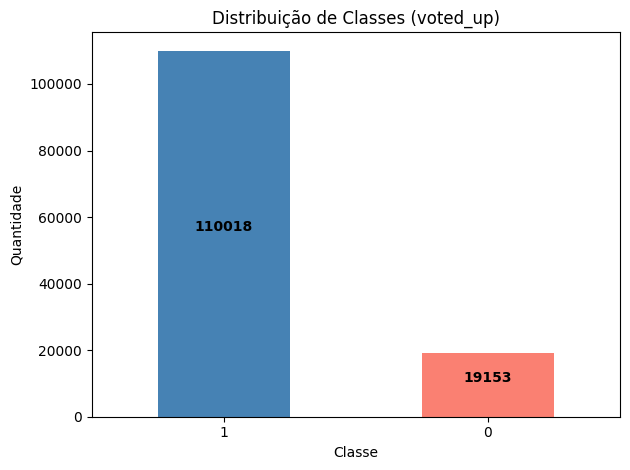

In [10]:
# Balanceamento das classes
df["voted_up"] = df["voted_up"].astype(int)
target = df["voted_up"].value_counts() # distribuição do target

# Gráfico de barras
ax = target.plot(kind='bar', color=['steelblue', 'salmon'])
for i, value in enumerate(target):
    plt.text(i, value / 2, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Distribuição de Classes (voted_up)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Antes de aplicar o balanceamento, a variável alvo voted_up foi convertida para o tipo inteiro e teve sua distribuição de classes analisada. Para isso, foi calculada a contagem de cada classe (0 = não recomenda, 1 = recomenda) com value_counts() e gerado um gráfico de barras mostrando quantas reviews pertencem a cada categoria.

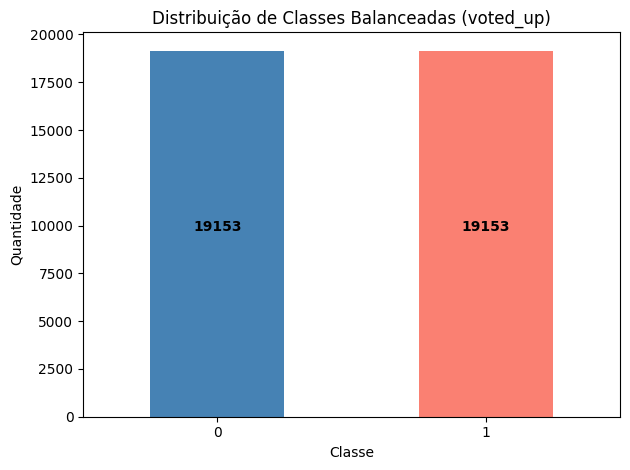

In [11]:
# Undersampling
X = df.drop(columns=["voted_up"])
y = df["voted_up"]

undersampler = RandomUnderSampler(random_state=42)

X_res, y_res = undersampler.fit_resample(X, y)

new_target = y_res.value_counts()

# Gráfico de barras
ax = new_target.plot(kind='bar', color=['steelblue', 'salmon'])
for i, value in enumerate(new_target):
    plt.text(i, value / 2, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Distribuição de Classes Balanceadas (voted_up)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Em seguida, foi realizado o balanceamento das classes por meio de undersampling. Para isso, a variável alvo voted_up foi separada das demais colunas (X e y), e foi utilizado o método RandomUnderSampler, da biblioteca imblearn, com random_state=42 para garantir reprodutibilidade. Esse procedimento reduz aleatoriamente a classe majoritária até que ambas as classes tenham a mesma quantidade de exemplos, gerando os conjuntos X_res e y_res balanceados. Após o reamostramento, foi gerado um novo gráfico de barras com a distribuição de voted_up, mostrando que as duas classes passaram a ter o mesmo número de instâncias, o que é importante para evitar que os modelos de classificação fiquem enviesados para a classe mais frequente.

In [12]:
# Dados balanceados
df_bal = X_res.copy()
df_bal["voted_up"] = y_res

# Movendo colunas
end_cols = ["review", "tokens", "no_stop_words", "lemma", "voted_up"]
initials_cols = [column for column in df_bal.columns if column not in end_cols]
df_bal = df_bal[initials_cols + end_cols]

# Salvando o dataset ajustado
df_bal.to_csv("adjusted_reviews.csv", index=False)

Após o balanceamento, foi criado um novo DataFrame df_bal a partir de X_res, ao qual a coluna voted_up reamostrada (y_res) foi adicionada. Em seguida, as colunas foram reorganizadas de forma a posicionar, ao final, as variáveis diretamente relacionadas ao texto (review, tokens, no_stop_words, lemma) e a variável alvo (voted_up), facilitando a leitura e o uso do dataset. Por fim, esse conjunto de dados já balanceado e pré-processado foi salvo no arquivo adjusted_reviews.csv, que serviu como base para a etapa de modelagem.

# Análise Exploratória

Nesta seção, são apresentadas as análises exploratórias realizadas sobre o conjunto de reviews da Steam após o pré-processamento. O objetivo da análise exploratória é entender melhor o comportamento dos dados antes da etapa de modelagem, examinando a distribuição da variável alvo (voted_up), a frequência das palavras mais comuns no corpus e os padrões gerais de vocabulário por meio de gráficos e nuvens de palavras. Essas visualizações ajudam a identificar possíveis vieses, confirmar se o balanceamento das classes foi efetivo e fornecer uma visão intuitiva sobre o conteúdo das avaliações dos usuários.

In [13]:
#Lê o dataset já pré-processado e balanceado
df = pd.read_csv("adjusted_reviews.csv")
print("Tamanho do corpus:", df.shape)
print(df.info())

Tamanho do corpus: (38306, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38306 entries, 0 to 38305
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   appid                        38306 non-null  int64  
 1   name                         38306 non-null  object 
 2   recommendationid             38306 non-null  int64  
 3   votes_up                     38306 non-null  int64  
 4   votes_funny                  38306 non-null  int64  
 5   weighted_vote_score          38306 non-null  float64
 6   comment_count                38306 non-null  int64  
 7   steam_purchase               38306 non-null  bool   
 8   received_for_free            38306 non-null  bool   
 9   written_during_early_access  38306 non-null  bool   
 10  timestamp_created            38306 non-null  int64  
 11  timestamp_updated            38306 non-null  int64  
 12  language                     38306 non-null

Para a etapa de análise exploratória, foi utilizado o arquivo adjusted_reviews.csv, que contém o conjunto de reviews já pré-processado e com as classes balanceadas. Após a leitura do arquivo com read_csv(), foram exibidas as dimensões do corpus e um resumo das variáveis por meio dos comandos shape e info(), permitindo verificar a estrutura final do dataset que servirá de base para as análises e para a modelagem.

In [14]:
# Converte para lista
df["lemma"] = df["lemma"].apply(ast.literal_eval)

# Lista achatada
tokens_bow = [
    w
    for toks in df["lemma"]
    for w in toks
    if w.isalpha() and len(w) > 1
]

Como a coluna lemma foi salva no CSV como texto, ela é inicialmente convertida de volta para listas de lemas com ast.literal_eval(). Em seguida, é construída uma lista achatada (tokens_bow) contendo todas as palavras do corpus: para cada review, percorremos os lemas e mantemos apenas tokens formados exclusivamente por letras (isalpha()) e com mais de um caractere. Esse filtro remove sinais, números e tokens pouco informativos, preparando uma base mais limpa para a construção do Bag-of-Words e das análises de frequência.

In [15]:
# Bag of words
bow = Counter(tokens_bow)
top_20 = bow.most_common(20) # seleciona as 20 palavras mais frequentes
print(top_20)

[('jogo', 38719), ('bom', 14235), ('jogar', 9914), ('pra', 9123), ('fazer', 6751), ('ir', 5698), ('todo', 5104), ('ea', 4646), ('poder', 4259), ('bem', 4175), ('ficar', 4023), ('ter', 3638), ('nao', 3417), ('game', 3324), ('dar', 3114), ('outro', 3089), ('ruim', 3055), ('ainda', 2977), ('tempo', 2775), ('algum', 2762)]


A partir da lista de tokens filtrados, foi construído um Bag-of-Words utilizando a classe Counter, que contabiliza quantas vezes cada palavra aparece no corpus. Em seguida, foram selecionadas as 20 palavras mais frequentes por meio do método most_common(20). Esse levantamento permite identificar os termos mais recorrentes nas reviews, servindo como base para interpretar o vocabulário dominante e relacioná-lo ao contexto de avaliação dos jogos.

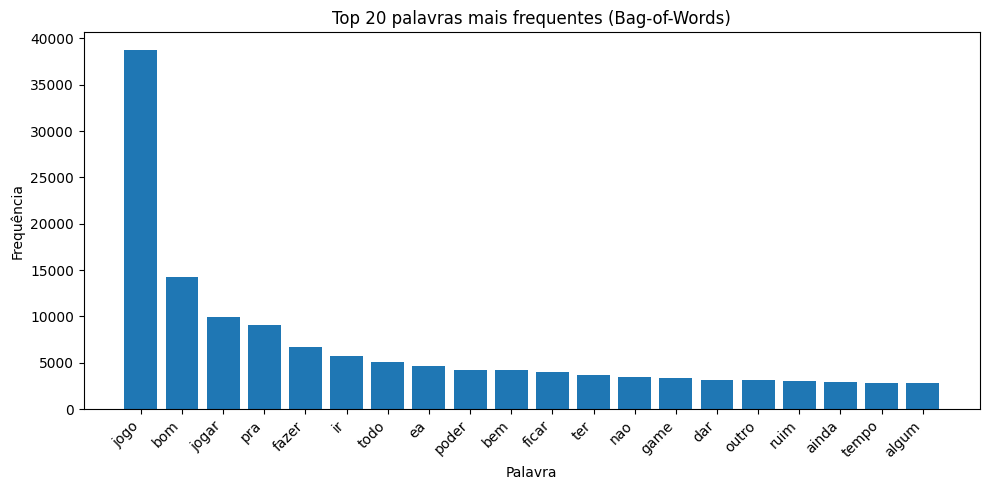

In [16]:
# Separa palavras e frequências em listas para plotar
words = [w for w, f in top_20]
frequencys = [f for w, f in top_20]

# Gráfico de barras do Top 20 do Bag-of-Words
plt.figure(figsize=(10, 5))
plt.bar(range(len(words)), frequencys)
plt.xticks(range(len(words)), words, rotation=45, ha='right')
plt.title("Top 20 palavras mais frequentes (Bag-of-Words)")
plt.xlabel("Palavra")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

As 20 palavras mais frequentes e suas contagens foram separadas em duas listas (words e frequencys) para facilitar a visualização. Em seguida, foi construído um gráfico de barras com essas informações, exibindo no eixo x as palavras mais comuns do corpus e, no eixo y, suas frequências. Esse gráfico de Top 20 ajuda a identificar quais termos aparecem com maior intensidade nas reviews, oferecendo uma visão geral do vocabulário predominante após o pré-processamento.

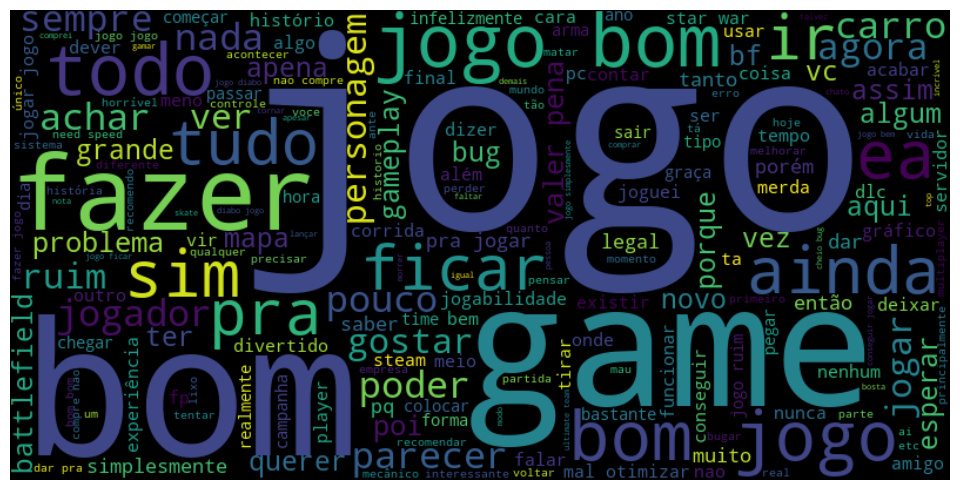

In [17]:
# Junta todos os tokens filtrados em uma única string
all_words = " ".join(tokens_bow)

# Cria a wordcloud
cloud = WordCloud(width=800, height=400, background_color="black")
cloud = cloud.generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off") # esconde os eixos para focar só na nuvem
plt.tight_layout()
plt.show()

Para complementar a análise de frequência, todos os tokens filtrados foram concatenados em uma única string (all_words), que serve de entrada para a função WordCloud. A partir desse texto, foi gerada uma nuvem de palavras, na qual o tamanho de cada termo é proporcional à sua frequência no corpus. Essa visualização permite identificar de forma intuitiva e rápida quais palavras se destacam nas reviews, facilitando a interpretação dos principais temas e impressões expressas pelos usuários.

# Modelo de Classificação de Texto

Nesta seção, são apresentados os modelos de classificação de texto utilizados para prever o sentimento das reviews da Steam, a partir da variável alvo voted_up (recomenda ou não o jogo). Após o pré-processamento e a representação das avaliações em formato vetorial (Bag-of-Words e TF-IDF), o problema foi formulado como uma tarefa de classificação binária supervisionada. Para isso, foram treinados e comparados dois algoritmos amplamente utilizados em Processamento de Linguagem Natural: o Naive Bayes Multinomial e a Regressão Logística. A seguir, descrevem-se as características de cada modelo, a forma de treinamento e os critérios adotados para avaliar o desempenho na tarefa de análise de sentimento.

In [18]:
# Texto lematizado em formato de string
df["lemma_text"] = df["lemma"].apply(lambda toks: " ".join(toks))

print(df[["lemma_text", "voted_up"]].head())

                                          lemma_text  voted_up
0  gostar paguei caro jogabilidade limitar re uti...         0
1                                            aaaaaaa         0
2  jogo deixar desejar ir ponto h história mio pe...         0
3  instaler versão passar amigo apenas maneira ve...         0
4  precisar fazer nada zerar jogo jogar sozinho i...         0


Para utilizar as reviews em modelos de classificação baseados em Bag-of-Words e TF-IDF, a lista de lemas de cada review foi convertida em uma string única. Isso foi feito criando-se a coluna lemma_text, na qual os lemas presentes em lemma são concatenados com espaços por meio de join(). Dessa forma, cada linha passa a representar o texto lematizado em formato contínuo, associado à sua respectiva classe na variável voted_up, o que facilita a aplicação dos vetorizadores da biblioteca scikit-learn.

In [19]:
# Treino e teste
X = df["lemma_text"]
y = df["voted_up"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantém a proporção de classes
)

target_names = ["Não recomenda (0)", "Recomenda (1)"]

Para a etapa de modelagem, utilizou-se a coluna lemma_text como variável de entrada (X) e a coluna voted_up, convertida para inteiro, como variável alvo (y). Em seguida, os dados foram divididos em conjuntos de treino e teste, na proporção de 80% e 20%, respectivamente, por meio da função train_test_split, com random_state=42 para garantir reprodutibilidade e stratify=y para preservar a proporção de classes em ambos os conjuntos. Também foi definido o vetor target_names com os rótulos “Não recomenda (0)” e “Recomenda (1)”, utilizado posteriormente na apresentação dos resultados dos modelos de classificação.

In [23]:
# TF-IDF e Bag-of-Words

# TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Bag-of-Words (CountVectorizer)
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

Para representar os textos em formato numérico, foram utilizadas duas estratégias clássicas: TF-IDF e Bag-of-Words. No primeiro caso, aplicou-se o TfidfVectorizer sobre o conjunto de treino (X_train), gerando a matriz X_train_tfidf com os pesos TF-IDF de cada termo, e depois a mesma transformação foi aplicada ao conjunto de teste (X_test) por meio de transform(). Em paralelo, foi construída uma representação Bag-of-Words usando o CountVectorizer, que produz as matrizes X_train_cv e X_test_cv com as contagens de ocorrência de cada palavra em cada review. Essas duas versões vetorizadas do corpus foram utilizadas posteriormente no treinamento e comparação dos modelos de classificação.


Regressão Logística (TF-IDF)
Acurácia: 0.8800574262594623
Relatório de classificação:

                   precision    recall  f1-score   support

Não recomenda (0)       0.88      0.87      0.88      3831
    Recomenda (1)       0.88      0.89      0.88      3831

         accuracy                           0.88      7662
        macro avg       0.88      0.88      0.88      7662
     weighted avg       0.88      0.88      0.88      7662

Matriz de confusão:
 [[3352  479]
 [ 440 3391]]


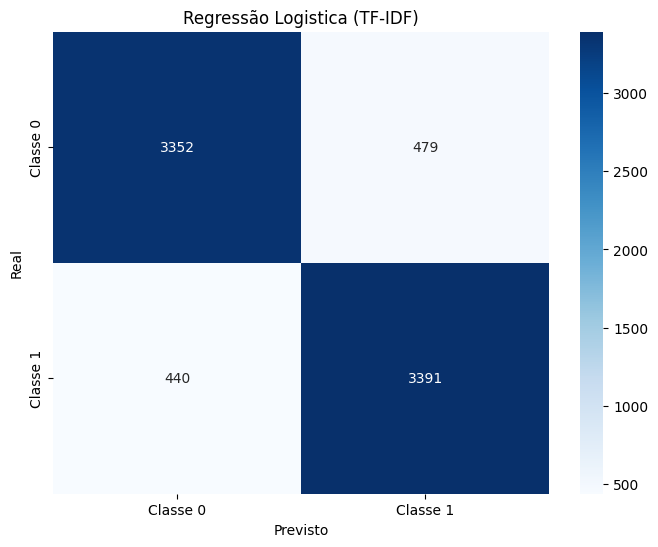

In [31]:
# Modelos com TF-IDF

# Regressão Logística + TF-IDF
lr_tfidf = LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)

predictions_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("\nRegressão Logística (TF-IDF)")
print("Acurácia:", accuracy_score(y_test, predictions_lr_tfidf))
print("Relatório de classificação:\n")
print(classification_report(y_test, predictions_lr_tfidf, target_names=target_names))
print("Matriz de confusão:\n", confusion_matrix(y_test, predictions_lr_tfidf))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predictions_lr_tfidf), annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Regressão Logistica (TF-IDF)')
plt.show()

Para avaliar o desempenho da Regressão Logística com representação TF-IDF, o modelo LogisticRegression foi treinado sobre a matriz X_train_tfidf e a variável alvo y_train. Em seguida, foram geradas as previsões para o conjunto de teste (X_test_tfidf) e calculadas métricas como acurácia, precisão, recall e f1-score por meio da função classification_report. Além disso, foi construída a matriz de confusão comparando os rótulos reais e previstos, e essa matriz foi visualizada em forma de mapa de calor com seaborn.heatmap. Essa visualização permite observar de maneira clara quantas reviews de cada classe foram corretamente classificadas e quantos erros ocorreram, ajudando a interpretar o comportamento do modelo na tarefa de prever se o usuário recomenda (classe 1) ou não recomenda (classe 0) o jogo.


Naive Bayes (TF-IDF)
Acurácia: 0.8525189245627773
Relatório de classificação:

                   precision    recall  f1-score   support

Não recomenda (0)       0.81      0.93      0.86      3831
    Recomenda (1)       0.92      0.77      0.84      3831

         accuracy                           0.85      7662
        macro avg       0.86      0.85      0.85      7662
     weighted avg       0.86      0.85      0.85      7662

Matriz de confusão:
 [[3564  267]
 [ 863 2968]]


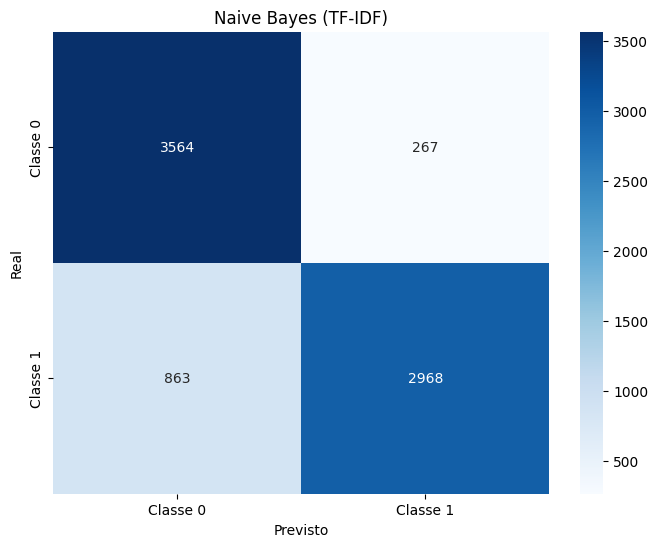

In [32]:
# Naive bayes + TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

nb_predictions_tfidf = nb_tfidf.predict(X_test_tfidf)

print("\nNaive Bayes (TF-IDF)")
print("Acurácia:", accuracy_score(y_test, nb_predictions_tfidf))
print("Relatório de classificação:\n")
print(classification_report(y_test, nb_predictions_tfidf, target_names=target_names))
print("Matriz de confusão:\n", confusion_matrix(y_test, nb_predictions_tfidf))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, nb_predictions_tfidf), annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Naive Bayes (TF-IDF)')
plt.show()

Em seguida, foi avaliado o desempenho do modelo Naive Bayes Multinomial utilizando a mesma representação TF-IDF. O classificador MultinomialNB foi treinado com a matriz X_train_tfidf e os rótulos y_train, e, a partir disso, gerou previsões para o conjunto de teste (X_test_tfidf). As métricas de acurácia, precisão, recall e f1-score foram obtidas com classification_report, permitindo comparar diretamente esse modelo com a Regressão Logística sob as mesmas condições. Também foi construída e visualizada a matriz de confusão em forma de mapa de calor, o que possibilita analisar em quais classes (0 = não recomenda, 1 = recomenda) o Naive Bayes acerta mais e em quais ele comete mais erros, ajudando a compreender seu comportamento na tarefa de classificação de sentimento.


Regressão Logística (Bag-of-Words)
Acurácia: 0.875097885669538
Relatório de classificação:

                   precision    recall  f1-score   support

Não recomenda (0)       0.90      0.84      0.87      3831
    Recomenda (1)       0.85      0.91      0.88      3831

         accuracy                           0.88      7662
        macro avg       0.88      0.88      0.87      7662
     weighted avg       0.88      0.88      0.87      7662

Matriz de confusão:
 [[3228  603]
 [ 354 3477]]


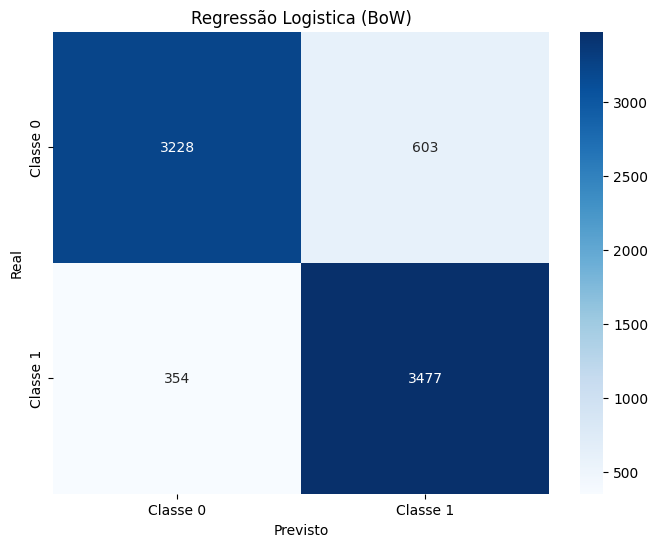

In [33]:
# Modelos com Bag-of-Words (bow)

# Regressão logística + bow
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_cv, y_train)

predictions_lr_bow = lr_bow.predict(X_test_cv)

print("\nRegressão Logística (Bag-of-Words)")
print("Acurácia:", accuracy_score(y_test, predictions_lr_bow))
print("Relatório de classificação:\n")
print(classification_report(y_test, predictions_lr_bow, target_names=target_names))
print("Matriz de confusão:\n", confusion_matrix(y_test, predictions_lr_bow))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predictions_lr_bow), annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Regressão Logistica (BoW)')
plt.show()

Também foi avaliado o desempenho da Regressão Logística utilizando a representação Bag-of-Words. Nesse caso, o modelo LogisticRegression foi treinado sobre a matriz X_train_cv, gerada pelo CountVectorizer, e testado em X_test_cv. A partir das previsões, foram calculadas as métricas de acurácia, precisão, recall e f1-score com classification_report, permitindo comparar diretamente esse cenário com a versão baseada em TF-IDF. A matriz de confusão resultante foi plotada em forma de mapa de calor, o que possibilita visualizar como o modelo se comporta ao classificar reviews das classes “não recomenda” (0) e “recomenda” (1) quando a representação do texto se baseia apenas em contagens de palavras (BoW).


Naive Bayes (Bag-of-Words)
Acurácia: 0.8565648655703472
Relatório de classificação:

                   precision    recall  f1-score   support

Não recomenda (0)       0.83      0.90      0.86      3831
    Recomenda (1)       0.89      0.81      0.85      3831

         accuracy                           0.86      7662
        macro avg       0.86      0.86      0.86      7662
     weighted avg       0.86      0.86      0.86      7662



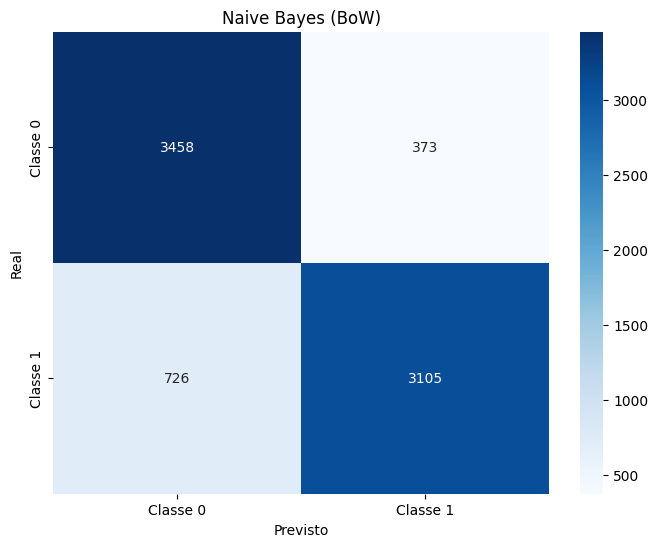

In [34]:
# Naive bayes + bow
nb_bow = MultinomialNB()
nb_bow.fit(X_train_cv, y_train)

nb_predictions_bow = nb_bow.predict(X_test_cv)

print("\nNaive Bayes (Bag-of-Words)")
print("Acurácia:", accuracy_score(y_test, nb_predictions_bow))
print("Relatório de classificação:\n")
print(classification_report(y_test, nb_predictions_bow, target_names=target_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, nb_predictions_bow), annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Naive Bayes (BoW)')
plt.show()

Por fim, o modelo Naive Bayes Multinomial também foi avaliado utilizando a representação Bag-of-Words. O classificador MultinomialNB foi treinado com a matriz X_train_cv, que contém as contagens de palavras geradas pelo CountVectorizer, e em seguida foram obtidas as previsões para o conjunto de teste (X_test_cv). A partir dessas previsões, calcularam-se acurácia, precisão, recall e f1-score com classification_report, permitindo comparar o desempenho do Naive Bayes tanto com BoW quanto com TF-IDF. A matriz de confusão correspondente foi representada por meio de um mapa de calor, evidenciando como o modelo acerta e erra na classificação das reviews entre as classes “não recomenda” (0) e “recomenda” (1) quando trabalha apenas com contagens de termos.

# Resultados:

Para avaliar o desempenho dos modelos de classificação de texto, foram utilizadas as métricas de acurácia, precisão, recall e f1-score, bem como a análise das matrizes de confusão. De modo geral, a Regressão Logística com representação TF-IDF apresentou o melhor desempenho global, com acurácia em torno de 0,88 e f1-score equilibrado entre as classes “não recomenda” (0) e “recomenda” (1). As matrizes de confusão mostraram que esse modelo cometeu quantidades semelhantes de falsos positivos e falsos negativos, indicando um comportamento estável e sem viés acentuado para uma das classes.

O modelo Naive Bayes Multinomial, também usando TF-IDF, obteve desempenho ligeiramente inferior, com acurácia menor e um desequilíbrio mais evidente entre as classes: tende a acertar mais a classe negativa ou positiva dependendo da representação, mas com trade-offs entre precisão e recall. Quando comparados os dois esquemas de representação, observou-se que TF-IDF, em geral, produziu resultados melhores ou semelhantes aos de Bag-of-Words para ambos os modelos, sugerindo que a ponderação dos termos por sua importância no corpus ajuda a capturar melhor os padrões de sentimento nas reviews.

Assim, a combinação Regressão Logística + TF-IDF se mostrou a configuração mais adequada para o problema proposto, conciliando boa acurácia com desempenho balanceado entre as duas classes. Os demais modelos (Naive Bayes com TF-IDF e as versões com Bag-of-Words) funcionam como baselines úteis para comparação, evidenciando o impacto tanto da escolha do algoritmo quanto da forma de representação textual na tarefa de análise de sentimento.